# Load, run, and plot a stock GMAT sample

This notebook walks through the canonical `gmat-run` loop end-to-end:

1. Locate a script that ships with your GMAT install.
2. Load it into the live GMAT object graph with `Mission.load`.
3. Run the mission and pull the resulting `ReportFile` back as a pandas DataFrame.
4. Compute altitude from the position vector and plot it with matplotlib.

We use `Ex_TLE_Propagation` — a one-day SGP4 propagation that ships with GMAT. It is small (~25 KB), runs in well under a second, and is exercised by `gmat-run`'s integration suite, so we know it round-trips cleanly through the API.

**Prerequisites.** A local GMAT install (R2026a is the primary development target) and `pip install gmat-run[examples]` for the matplotlib dependency.

## Locate the stock script

`gmat_run.locate_gmat()` returns a `GmatInstall` describing the resolved install — useful when you want to find files that ship with GMAT (samples, support data) without hard-coding a path.

In [1]:
import matplotlib.pyplot as plt

from gmat_run import Mission, locate_gmat

install = locate_gmat()
script_path = install.root / "samples" / "Ex_TLE_Propagation.script"

# Print install-relative path so the notebook output is machine-independent.
print(f"GMAT version: {install.version}")
print(f"Script:       <install>/{script_path.relative_to(install.root)}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       <install>/samples/Ex_TLE_Propagation.script
Exists:       True


## Load the mission

`Mission.load` parses the `.script` into the live GMAT object graph and bootstraps `gmatpy` for the discovered install. After load, subscript access reads and writes fields against that graph using dotted paths (`Resource.Field`). Reads return Python-typed values; writes coerce to the GMAT-expected type.

We don't actually need to override anything to run this script — but we'll read a couple of fields to confirm the load worked.

In [2]:
mission = Mission.load(script_path)

print(f"Spacecraft Id:           {mission['ExampleSat.Id']!r}")
print(f"Propagator type:         {mission['TLEProp.Type']!r}")
print(f"Initial step size (s):   {mission['TLEProp.InitialStepSize']}")

Spacecraft Id:           'ExampleSat'
Propagator type:         'SPICESGP4'
Initial step size (s):   300.0


## Run the mission

`mission.run()` executes the mission sequence headlessly and returns a `Results` object keyed by the resource names declared in the script. The script declares one `ReportFile` named `RF`, so the DataFrame is at `result.reports["RF"]`.

Parsing is lazy: the DataFrame is materialised on first access and cached. By default GMAT writes its outputs into a temporary directory whose lifetime is tied to the `Results` object — so the lazy access still works after `run()` returns.

In [3]:
result = mission.run()
df = result.reports["RF"]
df.head()

,ExampleSat.UTCGregorian,ExampleSat.X,ExampleSat.Y,ExampleSat.Z,ExampleSat.VX,ExampleSat.VY,ExampleSat.VZ
0,2002-05-04 11:45:15.695,-6775.105760,-2396.512640,3.177751,-0.366481,1.070980,7.362328
1,2002-05-04 11:50:15.695,-6557.983555,-1965.310636,2176.166250,1.802484,1.780535,7.006854
2,2002-05-04 11:55:15.695,-5710.959312,-1345.338768,4139.596094,3.798625,2.319176,5.976650
3,2002-05-04 12:00:15.695,-4315.504122,-596.168652,5704.506622,5.429061,2.634900,4.371784
4,2002-05-04 12:05:15.695,-2505.896415,210.221158,6720.611104,6.537478,2.697625,2.347662


Notice the `ExampleSat.UTCGregorian` column has dtype `datetime64[ns]` — `gmat-run` automatically promotes Gregorian and ModJulian epoch columns from text to typed timestamps at parse time, so plotting and time-series operations work without further wrangling.

In [4]:
df.dtypes

ExampleSat.UTCGregorian    datetime64[ns]
ExampleSat.X                      float64
ExampleSat.Y                      float64
ExampleSat.Z                      float64
ExampleSat.VX                     float64
ExampleSat.VY                     float64
ExampleSat.VZ                     float64
dtype: object

## Plot altitude over time

The `Ex_TLE_Propagation` ReportFile records position and velocity in inertial coordinates (`X`, `Y`, `Z`, `VX`, `VY`, `VZ`) but not altitude directly. Altitude is a derived quantity — for a spherical Earth it's $|\mathbf{r}| - R_\oplus$ where $R_\oplus$ is the Earth's equatorial radius. We compute it on the DataFrame and plot.

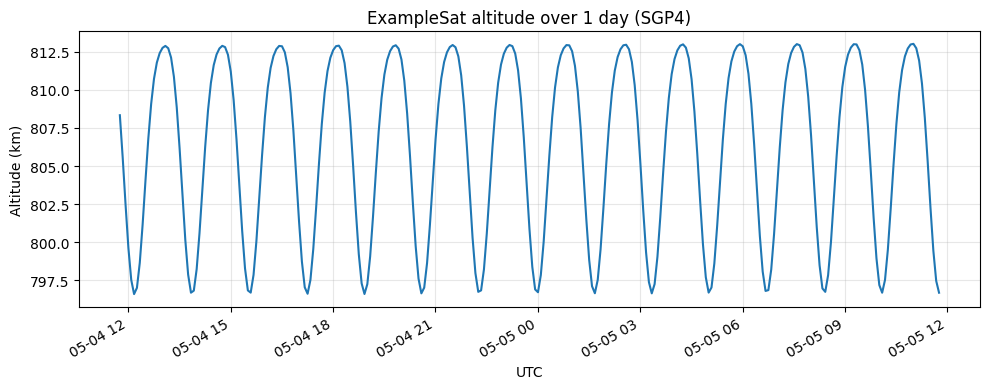

In [5]:
EARTH_RADIUS_KM = 6378.137  # WGS-84 equatorial radius

position = df[["ExampleSat.X", "ExampleSat.Y", "ExampleSat.Z"]]
df["Altitude_km"] = (position**2).sum(axis=1) ** 0.5 - EARTH_RADIUS_KM

fig, ax = plt.subplots(figsize=(10, 4))
df.plot(
    x="ExampleSat.UTCGregorian",
    y="Altitude_km",
    ax=ax,
    legend=False,
)
ax.set_xlabel("UTC")
ax.set_ylabel("Altitude (km)")
ax.set_title("ExampleSat altitude over 1 day (SGP4)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Where to next

- **Override script fields from Python.** The [Getting started guide](https://astro-tools.github.io/gmat-run/getting-started/) shows how to write to fields via subscript access (e.g. `mission['Sat.SMA'] = 7000`) before running.
- **Read other output types.** `Results` also exposes `.ephemerides` (CCSDS-OEM and STK-TimePosVel formats) and `.contacts` (`ContactLocator`) as DataFrames — see the [API reference](https://astro-tools.github.io/gmat-run/reference/).
- **Run from the shell.** The [`gmat-run` CLI](https://astro-tools.github.io/gmat-run/cli/) wraps the same load → run → write loop for shell scripts and smoke tests.